## Handwritten digits:

### Tasks - Part 0.

1) First thing, grab a piece of paper and visually classify those 25 digits. We'll see if you're better or worse than a computer! 

2) Here is how you plot the images and the corresponding labels  (The one thing I'm not telling you of course is the random seed I used to select those above). After you've seen this ones, go back to your piece of paper and update your choices if you want. Keep track of both set of preditions. This is like supervised learning.  

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import sklearn

In [2]:
from sklearn import datasets
digits = datasets.load_digits()
print(digits.images.shape)
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [3]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 1797
    :Number of Attributes: 64
    :Attribute Information: 8x8 image of integer pixels in the range 0..16.
    :Missing Attribute Values: None
    :Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
    :Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each blo

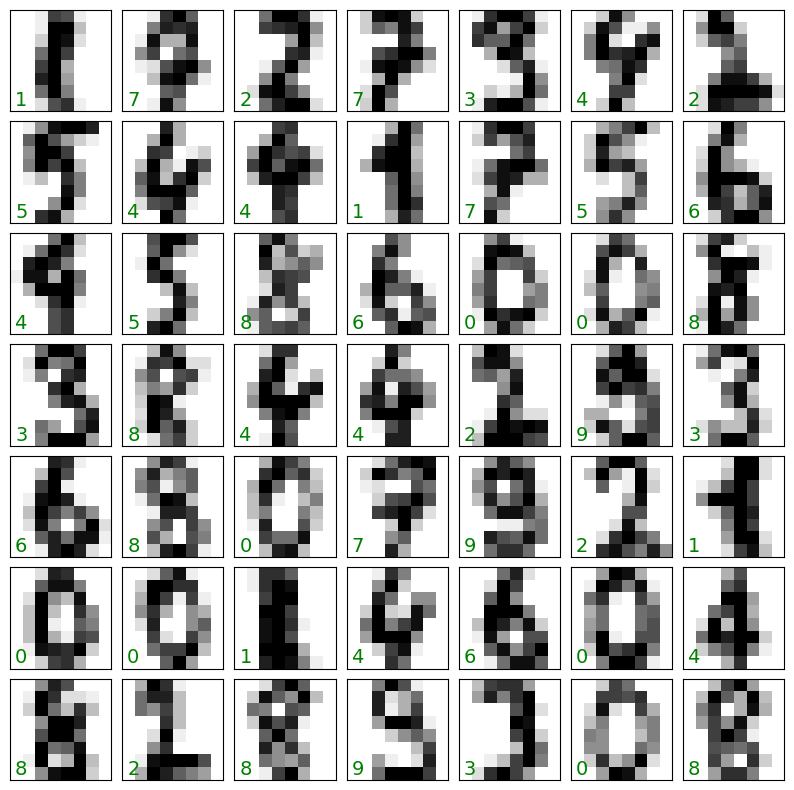

In [4]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])
    

Ok so the data is simply each pixel value within an $8\times 8$ grid.  For this analysis, we don't care about the $2$-D nature of the image, we can just treat it as an $8\times8=64$ dimensional array. So our data have $1797$ samples in $64$ dimensions.

Then each of the $1797$ ***images*** has a label.

In [5]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


### Part 1 - Unsupervised Learning: Dimensionality Reduction on Digits

We'd like to visualize our points within the 64-dimensional parameter space, but it's difficult to plot points in $N=64$ dimensions! So we need to reduce the dimensionality of the space


3) Use the unsupervised dimensionality reduction technique called **[`Isomap`](http://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html#sklearn.manifold.Isomap)**. Isomap is an embedding tecnique, which tries to understand if your $N$ dimensional datapoint live in a $N$ dimensional (with $N<M$) manyfold. Have a look at the Isomap documentation and reduce the MINST dataset.  Do some plots to visualize your results 

*Note*. Isomap is very recent. It was introduced by [Tenenbaum et al (2000)](https://www.science.org/doi/10.1126/science.290.5500.2319) ---a paper that has something like $1.5\times 10^4$ [citations](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=a+global+geometric+framework+for+nonlinear+dimensionality+reduction&btnG=).


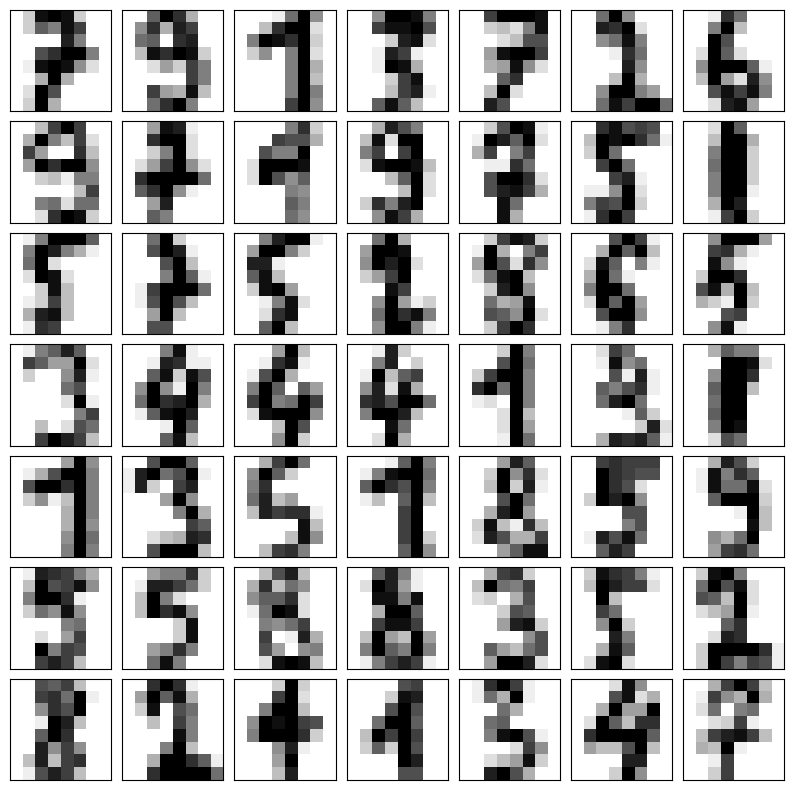

In [6]:
#Just checking if i can print some digits

my_data = np.random.choice(digits.images.shape[0],100)

fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[my_data[i]]), 
              cmap='binary')
    ax.set_xticks([])
    ax.set_yticks([])

In [7]:
from sklearn.manifold import Isomap
embedding = Isomap(n_components=2) #setting the new dimensionality to 2
digits.data.shape #checking the format of our data

(1797, 64)

In [8]:
new_data = embedding.fit_transform(digits.data)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/manifold/_isomap.py:373: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
/opt/anaconda3/lib/python3.11/site-packages/scipy/sparse/_index.py:100: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_intXint(row, col, x.flat[0])


Text(0.5, 0, 'X')

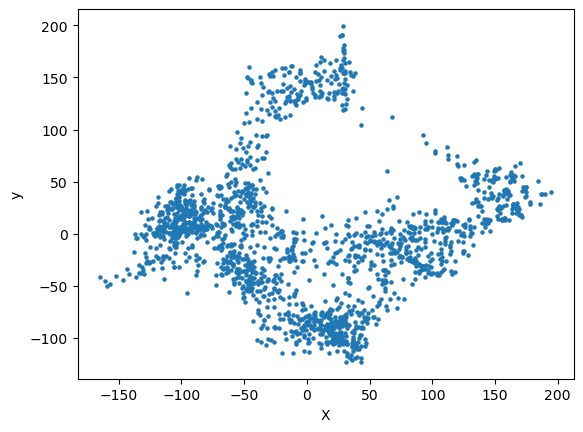

In [9]:
plt.scatter(new_data[:,0],new_data[:,1], s = 5)
plt.ylabel('y')
plt.xlabel('X')

### Part 2 - Supervised Learning: Classification on Digits

Now we want to classify the dataset. 

4) Split the dataset taking 80% of the images as tranining dataset and leaving the other 20% as a validation set. You need `sklearn.model_selection.train_test_split`.

5) Use a simple [`Logistic Regression`](http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) which despite its name is a common classification algorithm. (I know, this is confusing!). Use the flag `solver='sag'` (I found the default solver had a bug, at least when I tried).

6) Compute the accuracy (`sklearn.metrics.accuracy_score`) of your emulator. In this context, accuracy is simply the fraction of the digits that were correctly identified. Compute the accuracy on both the training and the validation set. Comment on the results.

7) The accuracy is a single number doesn't tell us ***where*** we've gone wrong. Plot the ***confusion matrix*** as we did above. What are the digits that are more challenging to identify, does it make sense?


There are many ways to improve this classifier, for example using a more sophisticated model, use cross validation, etc.  We'll get to those in the coming weeks.

In [10]:
labels = digits.target
train_data, test_data, train_lab, test_lab = sklearn.model_selection.train_test_split(new_data, labels, 
                                                                 test_size=0.2, train_size=0.8)

In [11]:
classif = sklearn.linear_model.LogisticRegression(solver = 'sag', random_state=0).fit(train_data, train_lab)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Text(0.5, 1.0, 'Actual labels')

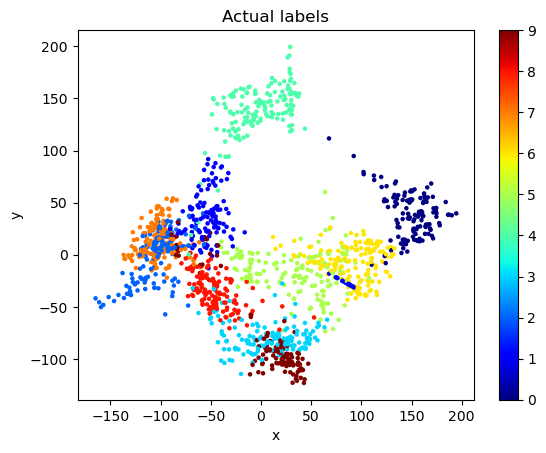

In [12]:
formatter = plt.FuncFormatter(lambda i, *args: digits.target_names[int(i)])

plt.scatter(train_data[:,0], train_data[:,1], s = 5, c = train_lab, cmap=plt.colormaps['jet'])
plt.colorbar(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], format = formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Actual labels')

In [13]:
guess_train = classif.predict(train_data)
guess_test = classif.predict(test_data)

Text(0.5, 1.0, 'Guessed labels')

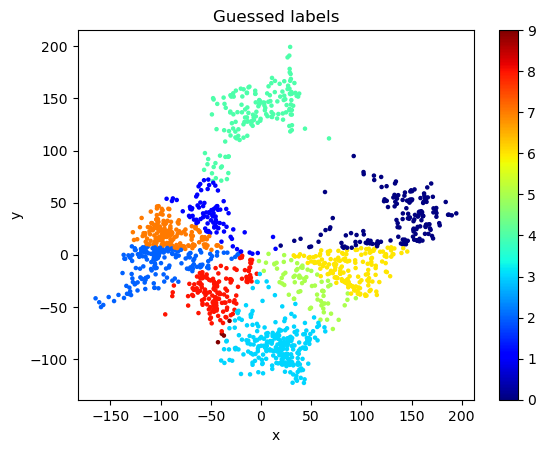

In [14]:
plt.scatter(train_data[:,0], train_data[:,1], s = 5, c = guess_train, cmap=plt.colormaps['jet'])
plt.colorbar(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], format = formatter)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Guessed labels')

In [15]:
acc_train = sklearn.metrics.accuracy_score(train_lab, guess_train)
acc_test = sklearn.metrics.accuracy_score(test_lab, guess_test)
print(f'Accuracy on the train set: {acc_train}')
print(f'Accuracy on the test set: {acc_test}')

Accuracy on the train set: 0.6339596381350034
Accuracy on the test set: 0.6527777777777778


The accuracy isn't much different between the train set and the test set! Also plotting the data with the lables given by our classification we see clearly where the algorithm has problems !

Text(0, 0.5, 'y')

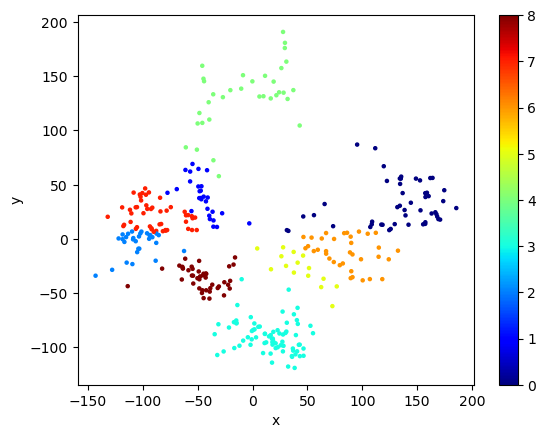

In [16]:
plt.scatter(test_data[:,0], test_data[:,1], s=5, c = guess_test, cmap=plt.colormaps['jet'])
plt.colorbar(ticks=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9], format = formatter)
plt.xlabel('x')
plt.ylabel('y')

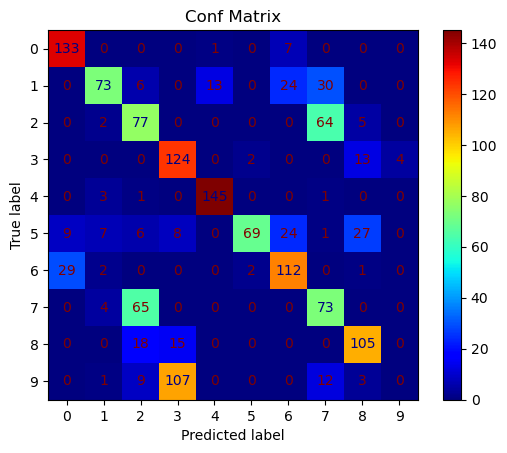

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
conf_matr = confusion_matrix(train_lab, guess_train)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matr, display_labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
disp.plot(cmap=plt.colormaps['jet'])
plt.title("Conf Matrix")
plt.show()

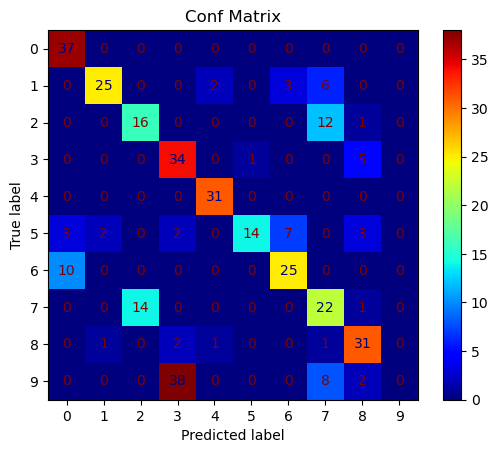

In [19]:
conf_test = confusion_matrix(test_lab, guess_test)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_test, display_labels=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])
disp.plot(cmap=plt.colormaps['jet'])
plt.title("Conf Matrix")
plt.show()

We can see that our classification algorithm does particularly poor with the following digits:

- 2 -> 7 (and also 8)
- 3 -> 9
- 7 -> 1, 2
- 9 -> 3

These numbers do in fact resamble eachother ! We mix them too by classifing 'by eye'!